![ITQ](imgLogo.png)
![ITQ](imgPortada.png)

Luis Pilaguano

# Visualización del límite de decisión del Perceptrón

### 1 Perceptrón: Caso práctico I

### 1.1 Dataset

El conjunto de datos flor Iris o conjunto de datos iris de Fisher es un conjunto de datos multivariante introducido por Ronald Fisher en su artículo de 1936, The use of multiple measurements in taxonomic problems (El uso de medidas múltiples en problemas taxonómicos) como un ejemplo de análisis discriminante lineal. A veces, se llama Iris conjunto de datos de Anderson porque Edgar Anderson coleccionó los datos para cuantificar la variación morfológica de la flor Iris de tres especies relacionadas. Dos de las tres especies se coleccionaron en la Península de la Gaspesia «todos son de la misma pastura, y recolectado el mismo día y medidos al mismo tiempo por la misma persona con el mismo aparato». El conjunto de datos contiene 50 muestras de cada una de tres especies de Iris (Iris setosa, Iris virginica e Iris versicolor). Se midió cuatro rasgos de cada muestra: el largo y ancho del sépalo y pétalo, en centímetros. Basado en la combinación de estos cuatro rasgos, Fisher desarrolló un modelo discriminante lineal para distinguir entre una especie y otra.

### 1.2 Enunciado

En este ejercicio vamos utilizar el conjunto de datos Iris para evaluar el funcionamiento del perceptrón y visualizar las capacidades que nos proporciona a la hora de clasificar diferentes categorías dentro de un conjunto de datos.

1.3 1. Lectura del conjunto de datos

In [2]:
from sklearn.datasets import load_iris

In [3]:
# Cargamos el conjunto de datos 
iris_dataset = load_iris()

In [4]:
# Visualizamos las etiquetas del conjunto de datos 
iris_dataset.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
iris_dataset.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [5]:
# Leemos el conjunto de datos con la librería Pandas
import pandas as pd
import numpy as np

df = pd.DataFrame(
    np.c_[iris_dataset['data'], iris_dataset['target']], 
    columns=iris_dataset['feature_names'] + ['target']
)

df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


### 1.4 2. Visualización del conjunto de datos

Ingrese el valor de petal length (cm):  1.4
Ingrese el valor de petal width (cm):  0.2


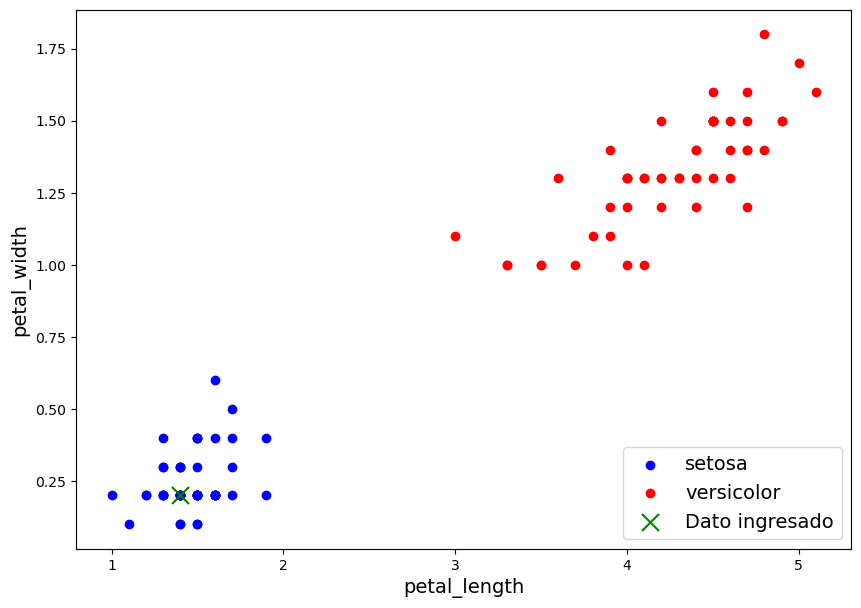

In [21]:
# Representación gráfica de dos dimensiones del conjunto de datos
import matplotlib.pyplot as plt

# Gráfico de los datos originales
fig = plt.figure(figsize=(10, 7))

plt.scatter(
    df["petal length (cm)"][df["target"] == 0],
    df["petal width (cm)"][df["target"] == 0],
    c="b",
    label="setosa"
)

plt.scatter(
    df["petal length (cm)"][df["target"] == 1],
    df["petal width (cm)"][df["target"] == 1],
    c="r",
    label="versicolor"
)

# === Ingreso de datos por teclado ===
try:
    petal_length = float(input("Ingrese el valor de petal length (cm): "))
    petal_width = float(input("Ingrese el valor de petal width (cm): "))

    # Dibujamos el punto ingresado en verde
    plt.scatter(petal_length, petal_width, c="g", marker="x", s=150, label="Dato ingresado")

except ValueError:
    print("Error: debe ingresar valores numéricos.")

# Configuración del gráfico
plt.xlabel("petal_length", fontsize=14)
plt.ylabel("petal_width", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.show()



Ingrese el valor de petal length (cm):  1.4
Ingrese el valor de petal width (cm):  0.2
Ingrese el valor de sepal width (cm):  3.5


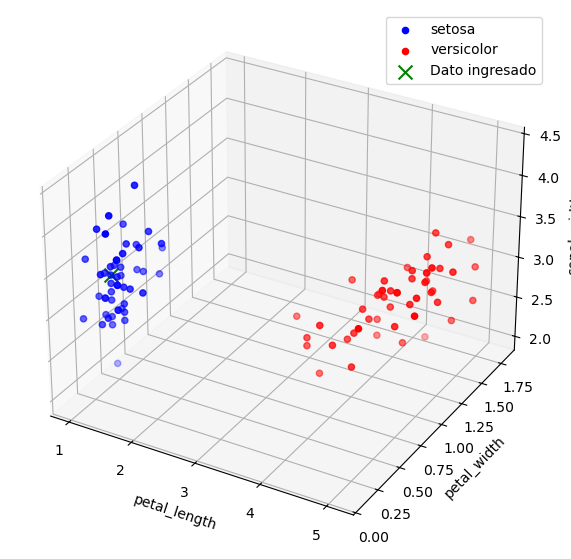

In [22]:
# Representación gráfica de tres dimensiones del conjunto de datos
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection="3d")

# Scatter para la clase 0
ax.scatter3D(
    df["petal length (cm)"][df["target"] == 0],
    df["petal width (cm)"][df["target"] == 0],
    df["sepal width (cm)"][df["target"] == 0],
    c="b",
    label="setosa"
)

# Scatter para la clase 1
ax.scatter3D(
    df["petal length (cm)"][df["target"] == 1],
    df["petal width (cm)"][df["target"] == 1],
    df["sepal width (cm)"][df["target"] == 1],
    c="r",
    label="versicolor"
)

# === Ingreso de datos por teclado ===
try:
    petal_length = float(input("Ingrese el valor de petal length (cm) ej (1.4): "))
    petal_width = float(input("Ingrese el valor de petal width (cm): (0.2)"))
    sepal_width = float(input("Ingrese el valor de sepal width (cm): (3.5)"))

    # Dibujar el punto ingresado en verde
    ax.scatter3D(petal_length, petal_width, sepal_width,
                 c="g", marker="x", s=100, label="Dato ingresado")

except ValueError:
    print("Error: debe ingresar valores numéricos.")

# Configuración del gráfico
ax.set_xlabel("petal_length")
ax.set_ylabel("petal_width")
ax.set_zlabel("sepal_width")
ax.legend()
plt.show()


Ingrese el valor de petal length (cm):  1.4
Ingrese el valor de petal width (cm):  0.2
Ingrese el valor de sepal width (cm):  3.5


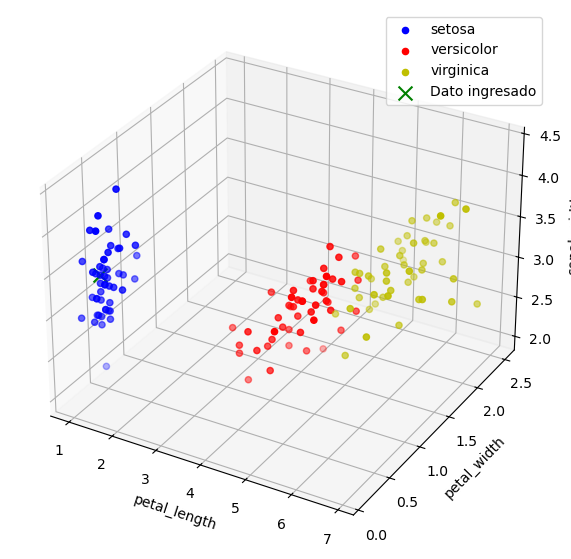

In [23]:
# Representación gráfica de tres dimensiones del conjunto de datos
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection="3d")

# Scatter para la clase 0
ax.scatter3D(
    df["petal length (cm)"][df["target"] == 0],
    df["petal width (cm)"][df["target"] == 0],
    df["sepal width (cm)"][df["target"] == 0],
    c="b",
    label="setosa"
)

# Scatter para la clase 1
ax.scatter3D(
    df["petal length (cm)"][df["target"] == 1],
    df["petal width (cm)"][df["target"] == 1],
    df["sepal width (cm)"][df["target"] == 1],
    c="r",
    label="versicolor"
)

# Scatter para la clase 2
ax.scatter3D(
    df["petal length (cm)"][df["target"] == 2],
    df["petal width (cm)"][df["target"] == 2],
    df["sepal width (cm)"][df["target"] == 2],
    c="y",
    label="virginica"
)

# === Ingreso de datos por teclado ===
try:
    petal_length = float(input("Ingrese el valor de petal length (cm): "))
    petal_width = float(input("Ingrese el valor de petal width (cm): "))
    sepal_width = float(input("Ingrese el valor de sepal width (cm): "))

    # Dibujar el punto ingresado en verde
    ax.scatter3D(petal_length, petal_width, sepal_width,
                 c="g", marker="x", s=100, label="Dato ingresado")

except ValueError:
    print("Error: debe ingresar valores numéricos.")

# Configuración del gráfico
ax.set_xlabel("petal_length")
ax.set_ylabel("petal_width")
ax.set_zlabel("sepal_width")
ax.legend()
plt.show()


### 1.5 3. Entrenamiento del algoritmo

In [8]:
# Reducimos el conjunto de datos para entrenar el algoritmo y visualizar el resultado
df_reduced = df[["petal length (cm)", "petal width (cm)", "target"]]
df_reduced = df_reduced.loc[df_reduced["target"].isin([0, 1])]

df_reduced


,petal length (cm),petal width (cm),target
0,1.4,0.2,0.0
1,1.4,0.2,0.0
2,1.3,0.2,0.0
3,1.5,0.2,0.0
4,1.4,0.2,0.0
...,...,...,...
95,4.2,1.2,1.0
96,4.2,1.3,1.0
97,4.3,1.3,1.0
98,3.0,1.1,1.0


In [9]:
# Separamos las etiquetas de salida del resto de características del conjunto de datos
X_df = df_reduced[["petal length (cm)", "petal width (cm)"]]
y_df = df_reduced["target"]


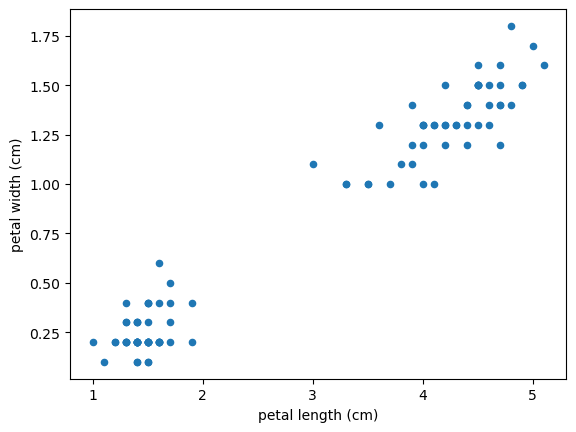

In [10]:
# Visualizamos el conjunto de datos de entrenamiento reducido
X_df.plot.scatter("petal length (cm)", "petal width (cm)")
plt.show()


In [11]:
y_df

0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
95    1.0
96    1.0
97    1.0
98    1.0
99    1.0
Name: target, Length: 100, dtype: float64

In [12]:
from sklearn.linear_model import Perceptron

clf = Perceptron(max_iter=1000, random_state=40)
clf.fit(X_df, y_df)


Perceptron(random_state=40)

## 1.6 Visualizacion del limite de decision construido por el algoritmo

In [13]:
# Parametros del modelo 
clf.coef_

array([[0.9, 1.3]])

In [14]:
# Terminio de interceptacion 
clf.intercept_

array([-3.])

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


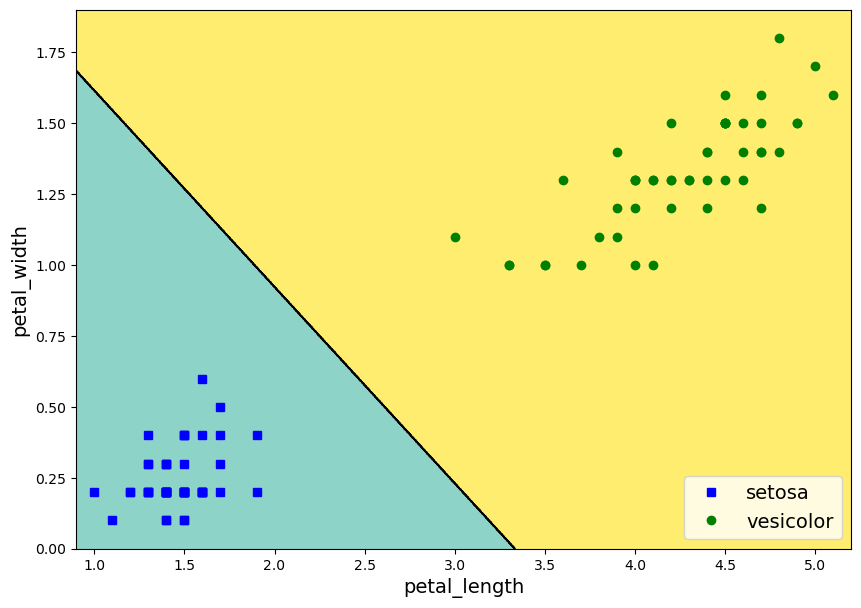

In [15]:
# Representacion grafica del limite de decision
import numpy as np

X = X_df.values
mins = X.min(axis=0) - 0.1
maxs = X.max(axis=0) + 0.1

# Calculamos valores intermedios entre el maximo y minimo
xx, yy = np.meshgrid(
    np.linspace(mins[0], maxs[0], 1000),
    np.linspace(mins[1], maxs[1], 1000)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, cmap="Set3")
plt.contour(
    Z,
    extent=(mins[0], maxs[0], mins[1], maxs[1]),
    linewidths=1,
    colors='k'
)

plt.plot(X[:, 0][y_df == 0], X[:, 1][y_df == 0], 'bs', label="setosa")
plt.plot(X[:, 0][y_df == 1], X[:, 1][y_df == 1], 'go', label="vesicolor")

plt.xlabel("petal_length", fontsize=14)
plt.ylabel("petal_width", fontsize=14)
plt.legend(loc="lower right", fontsize=14)
plt.show()


In [16]:
from sklearn.linear_model import Perceptron 
clf = Perceptron(max_iter=1000, random_state=40) 
clf.fit(X_df, y_df)

Perceptron(random_state=40)

In [17]:
y_pred = clf.predict(X_df)

In [18]:
y_pred = clf.predict(X_df)

In [19]:
from sklearn.metrics import accuracy_score

In [20]:
accuracy_score(y_df, y_pred)

1.0

[Repositorio segundo parcial](https://github.com/HLuiss17/Pr-cticas_Aprendizajee_Autom-tico_2/tree/master/segundoParcial)
